# Lecture 22 notebook: Nonlinear multi-parameter fitting with PyTorch

In the previous lecture, the class moved from manual scanning to automated optimization with PyTorch. In this notebook, we continue that story with **more difficult nonlinear models** and **noisy data**.

We will study **two examples**:

1. a **2-parameter nonlinear logistic-growth model** fit to noisy data,
2. a **6-parameter two-peak Gaussian model** fit to noisy data.

These two examples are deliberately different.

- The first example still looks like the ODE-based fitting problems from the previous lecture.
- The second example shows that PyTorch optimization is not only for ODE solvers. Once a model is differentiable, PyTorch can optimize its parameters automatically.

## 1. Import the libraries and set a random seed

In the next cell, we import the two libraries we need:

- `torch` for tensors, model evaluation, automatic differentiation, and optimization,
- `matplotlib.pyplot` for visualizing the data, the fitted curves, and the loss history.

We also set a random seed.

Why do that?

Because both of our data sets will include **random noise**. If we do not fix the random seed, then every run of the notebook will create slightly different noisy data. That makes it harder to discuss results consistently in class.

By setting the seed, the same synthetic data are generated every time, so everyone can follow exactly the same examples.

In [2]:
import torch
import matplotlib.pyplot as plt
torch.manual_seed(21)

## 2. Example 1 overview: a 2-parameter nonlinear logistic-growth model

Our first model is the **logistic growth equation**

$$
\frac{dy}{dt} = r y\left(1 - \frac{y}{K}\right) = ry - \frac{ry^2}{K},
$$

with initial value

$$
y(0) = y_0.
$$

The two unknown parameters are:

- $r$: the growth-rate parameter,
- $K$: the carrying capacity.

Why is this a good 2-parameter example?

Because it is clearly **nonlinear**: the right-hand side contains the product

$$
y\left(1 - \frac{y}{K}\right),
$$

so the growth rate depends on the current size of the solution itself. This is already richer than a simple linear decay model.

It is also a model where **both parameters matter in a meaningful way**:

- changing $r$ changes how quickly the solution rises,
- changing $K$ changes the long-term plateau level.

## 3. Create noisy data for the logistic-growth example

In the next cell, we build a synthetic data set for Example 1.

The workflow is:

1. choose a time grid,
2. choose a starting value $y_0$,
3. choose the true parameters $r_{true}$ and $K_{true}$,
4. solve the logistic ODE numerically,
5. add random noise to imitate measurement error.

Parameter estimation is designed for these types of problems:

- there is an underlying physical or biological process,
- the measurements are noisy,
- the true parameters are unknown,
- we want to recover them from the data.

We will use a Forward Euler solver so that the notebook still connects directly to the numerical-ODE work from the last lecture.

In [3]:
t1 = torch.linspace(0.0, 10.0, 41)   # 41 observation times from 0 to 10
y0_1 = torch.tensor(0.5)

r_true = torch.tensor(0.95)
K_true = torch.tensor(7.5)

def logistic_forward_euler(r, K, t_grid, y0):
    dt = t_grid[1] - t_grid[0]
    y = y0
    values = [y]

    for _ in range(len(t_grid) - 1):
        y = y + dt * (r * y * (1.0 - y / K))
        values.append(y)

    return torch.stack(values)

y1_clean = logistic_forward_euler(r_true, K_true, t1, y0_1)
y1_obs = y1_clean + 0.18 * torch.randn_like(y1_clean)

## 4. Plot the noisy data for Example 1

Before fitting anything, we should always look at the data.

That sounds obvious, but it is one of the most important habits in scientific computing.

If you skip the plot and go straight to optimization, you can easily miss the basic shape of what the model is supposed to explain.

In this data set, we expect to see:

- small values at early times,
- rapid growth in the middle,
- flattening toward a plateau at later times.

That shape is exactly why a logistic model makes sense.

The points will not lie perfectly on a smooth curve because we deliberately added noise.

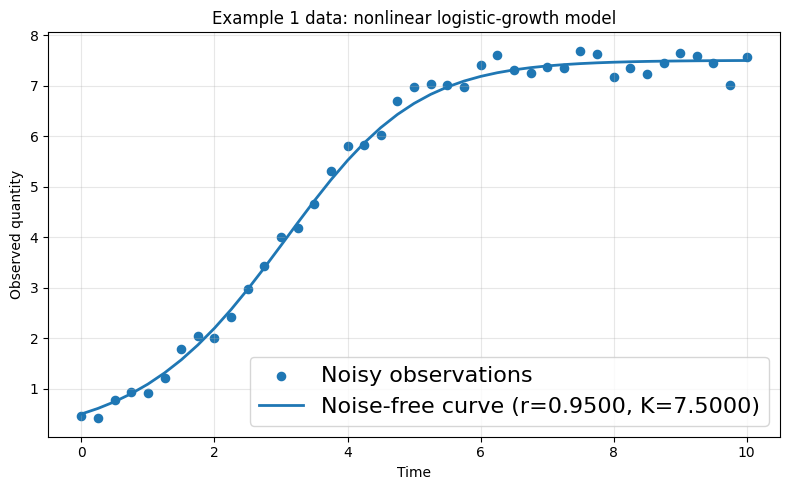

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(t1, y1_obs, s=35, label="Noisy observations")
plt.plot(t1, y1_clean, linewidth=2, label=f"Noise-free curve (r={r_true:.4f}, K={K_true:.4f})")
plt.xlabel("Time")
plt.ylabel("Observed quantity")
plt.title("Example 1 data: nonlinear logistic-growth model")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

## 5. Define the loss function for Example 1

To fit the model, we need a single number that tells us how good or bad a parameter choice is.

We will use the **mean squared error**:

$$
L(r, K) = \frac{1}{N} \sum_{i=1}^{N} \left(y_i^{pred} - y_i^{obs}\right)^2.
$$

Interpretation:

- compute the prediction at every observation time,
- subtract the observed data value,
- square each difference,
- average the squared differences.

Why use the square?

Because:

- positive and negative errors should not cancel,
- large mistakes should be penalized more heavily than small ones.

The next cell wraps this into a function so that we can call it repeatedly during optimization.

In [5]:
def logistic_loss(r, K):
    y_pred = logistic_forward_euler(r, K, t1, y0_1)
    return torch.mean((y_pred - y1_obs) ** 2)

## 6. Make the two parameters learnable

PyTorch optimizers work by updating tensors that have `requires_grad=True`.

However, in this model the parameters $r$ and $K$ should stay **positive**:

- a negative growth rate would completely change the meaning of the model,
- a negative carrying capacity would not make physical sense here.

A common trick is therefore:

1. optimize unrestricted **raw parameters**,
2. transform them into positive parameters using the `softplus` function.

A `softplus` function looks like this: 

$$
\text{softplus}(x) = \ln(1 + e^x) > 0 
$$

So instead of optimizing $r$ and $K$ directly, we optimize `raw_r` and `raw_K`, then define

$$
r = \operatorname{softplus}(\text{raw\_r}), \qquad
K = \operatorname{softplus}(\text{raw\_K}).
$$

This gives the optimizer freedom to move in all directions while still keeping the interpreted parameters positive.

In [6]:
raw_r = torch.tensor(-0.20, requires_grad=True)
raw_K = torch.tensor(1.00, requires_grad=True)

optimizer1 = torch.optim.Adam([raw_r, raw_K], lr=0.08)
loss_history_1 = []
param_history_1 = []

## 7. Run PyTorch optimization for Example 1

This next code cell is the most important part of the fitting process.

Each pass through the loop performs four key steps:

1. `optimizer1.zero_grad()`  
   This clears out gradients from the previous iteration. PyTorch accumulates gradients by default, so if we do not reset them, the new derivatives would be added to the old ones.

2. compute the current parameters and the current loss  
   We convert the raw parameters into positive parameters, solve the model, and evaluate the mismatch with the observed data.

3. `loss.backward()`  
   This tells PyTorch to apply automatic differentiation and compute the partial derivatives of the loss with respect to the raw parameters.

4. `optimizer1.step()`  
   This uses those gradients to update the raw parameters in a direction that should reduce the loss.

We also store the loss and the parameter values at each iteration so that we can later visualize how the optimization behaved.

In [7]:
for step in range(1200):
    optimizer1.zero_grad()

    r_est = torch.nn.functional.softplus(raw_r) + 1.0e-4
    K_est = torch.nn.functional.softplus(raw_K) + 1.0e-4

    loss = logistic_loss(r_est, K_est)
    loss.backward()
    optimizer1.step()

    loss_history_1.append(loss.item())
    param_history_1.append([r_est.item(), K_est.item()])

## 8. Plot the loss history for Example 1

A good fit is not only about the final answer. It is also useful to see **how the optimizer got there**.

The loss-history plot answers questions like:

- Did the optimizer steadily improve the fit?
- Did it make fast progress at the beginning and then slow down?
- Did it become unstable or oscillatory?

In a successful run, we expect the loss to drop sharply at first and then gradually level off as the optimizer approaches a minimum.

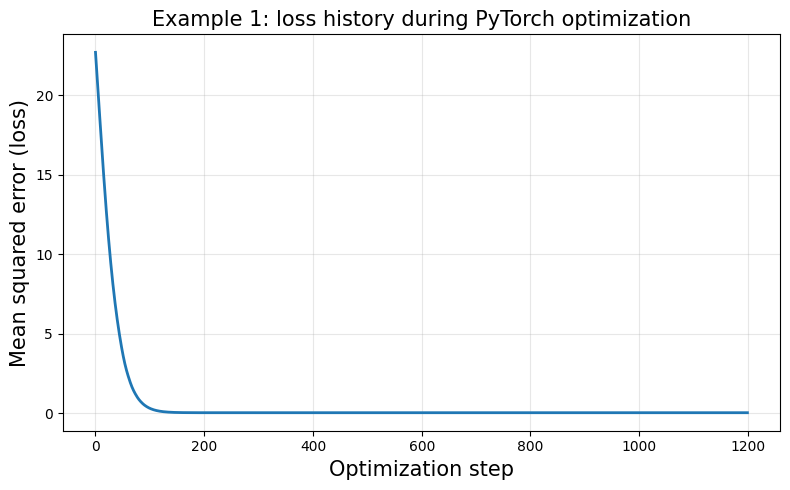

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_1, linewidth=2)
plt.xlabel("Optimization step", fontsize=15)
plt.ylabel("Mean squared error (loss)", fontsize=15)
plt.title("Example 1: loss history during PyTorch optimization", fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Compare the fitted curve to the noisy data for Example 1

Now we extract the final fitted parameters and compare the model prediction to the data.

This is the main scientific question:

> Does the optimized model actually explain the observed measurements well?

The next cell will:

- compute the final parameter estimates,
- generate the fitted solution curve,
- overlay the fitted curve, the noisy data, and the original noise-free curve,
- print the true and recovered parameter values.

This lets us judge both:

- the visual quality of the fit,
- the numerical accuracy of the recovered parameters.

True r = 0.9500, fitted r = 0.9648
True K = 7.5000, fitted K = 7.4923
Final loss = 0.031155


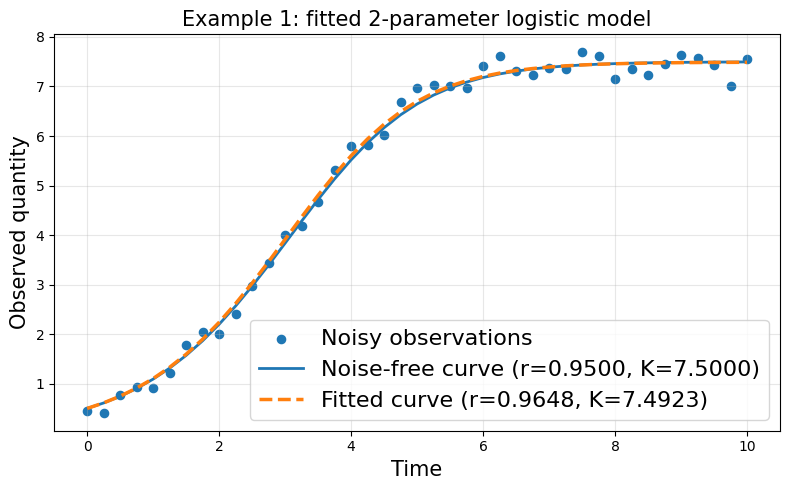

In [9]:
r_fit = torch.nn.functional.softplus(raw_r).detach() + 1.0e-4
K_fit = torch.nn.functional.softplus(raw_K).detach() + 1.0e-4
y1_fit = logistic_forward_euler(r_fit, K_fit, t1, y0_1)

print(f"True r = {r_true.item():.4f}, fitted r = {r_fit.item():.4f}")
print(f"True K = {K_true.item():.4f}, fitted K = {K_fit.item():.4f}")
print(f"Final loss = {loss_history_1[-1]:.6f}")

plt.figure(figsize=(8, 5))
plt.scatter(t1, y1_obs, s=35, label="Noisy observations")
plt.plot(t1, y1_clean, linewidth=2, label=f"Noise-free curve (r={r_true:.4f}, K={K_true:.4f})")
plt.plot(t1, y1_fit, "--", linewidth=2.5, label=f"Fitted curve (r={r_fit:.4f}, K={K_fit:.4f})")
plt.xlabel("Time", fontsize=15)
plt.ylabel("Observed quantity", fontsize=15)
plt.title("Example 1: fitted 2-parameter logistic model", fontsize=15)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

## 10. What Example 1 teaches us

This first example shows several important ideas clearly:

- even a model with only two parameters can already be meaningfully nonlinear,
- noisy data do not prevent parameter recovery,
- PyTorch can optimize through a numerical time-stepping scheme,
- automatic optimization is much easier than manually trying many different guesses (that we did in grid search).

But this is still a relatively small problem.

So now we move to something more flexible: a **6-parameter nonlinear model**.

## 11. Example 2 overview: a 6-parameter two-peak Gaussian model

In many applications, the data do not look like one smooth rise or one smooth decay.

Instead, the signal may contain **multiple peaks**.

A simple but very useful model for such data is a sum of two Gaussian peaks:

$$
y(x) = A_1 \exp\left(-\frac{(x-\mu_1)^2}{2\sigma_1^2}\right)
     + A_2 \exp\left(-\frac{(x-\mu_2)^2}{2\sigma_2^2}\right).
$$

An example figure with two Gaussian peaks is given below:

<p align="center">
<img src="two_peaks.png" width="400">
</p>

This model has **six parameters**:

- $A_1$: amplitude of the first peak,
- $\mu_1$: center of the first peak,
- $\sigma_1$: width of the first peak,
- $A_2$: amplitude of the second peak,
- $\mu_2$: center of the second peak,
- $\sigma_2$: width of the second peak.

Why is a 6-parameter model useful here?

Because if the data genuinely contain **two different peaks**, then one peak is not enough. Each peak needs:

- a height,
- a location,
- a width.

These are the situations in which six parameters models arise naturally.

## 12. Create noisy data for the 6-parameter example

In the next cell, we construct a synthetic signal with two peaks and then add noise.

This gives us a realistic parameter-estimation problem:

- the data are more complicated than a one-peak curve,
- several parameters interact,
- different bad parameter choices can fail in different ways.

For example:

- the peak heights may be wrong,
- the peak centers may be shifted,
- the widths may be too wide or too narrow.

This makes it a very good demonstration of why automated optimization matters.

In [10]:
torch.manual_seed(21)

x2 = torch.linspace(0.0, 20.0, 220)

A1_true = torch.tensor(2.4)
mu1_true = torch.tensor(5.0)
sigma1_true = torch.tensor(1.1)

A2_true = torch.tensor(1.7)
mu2_true = torch.tensor(13.2)
sigma2_true = torch.tensor(1.9)

def two_peak_model(x, A1, mu1, sigma1, A2, mu2, sigma2):
    peak1 = A1 * torch.exp(-0.5 * ((x - mu1) / sigma1) ** 2)
    peak2 = A2 * torch.exp(-0.5 * ((x - mu2) / sigma2) ** 2)
    return peak1 + peak2

y2_clean = two_peak_model(x2, A1_true, mu1_true, sigma1_true,
                          A2_true, mu2_true, sigma2_true)

y2_obs = y2_clean + 0.08 * torch.randn_like(y2_clean)

## 13. Plot the noisy data for Example 2

Again, the first serious step is to look at the data.

This plot should show:

- one bump near the first center,
- another bump near the second center,
- random noise around the true signal.

Even before fitting, you should be able to see that a single-peak model would be too limited. The data structure itself is already telling us that a richer model is needed.

True parameters:
  Peak 1: A=2.4000, mu=5.0000, sigma=1.1000
  Peak 2: A=1.7000, mu=13.2000, sigma=1.9000


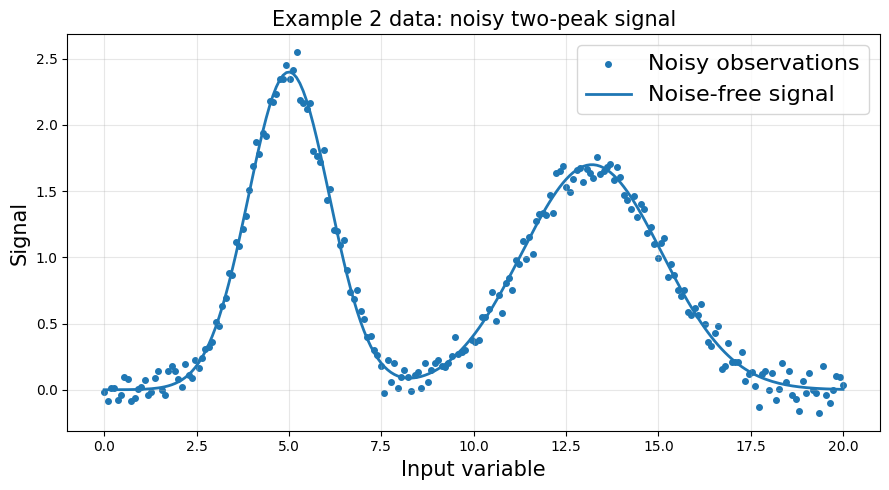

In [19]:
print(f"True parameters:")
print(f"  Peak 1: A={A1_true.item():.4f}, mu={mu1_true.item():.4f}, sigma={sigma1_true.item():.4f}")
print(f"  Peak 2: A={A2_true.item():.4f}, mu={mu2_true.item():.4f}, sigma={sigma2_true.item():.4f}")
plt.figure(figsize=(9, 5))
plt.scatter(x2, y2_obs, s=16, label="Noisy observations")
plt.plot(x2, y2_clean, linewidth=2, label=f"Noise-free signal")
plt.xlabel("Input variable", fontsize=15)
plt.ylabel("Signal", fontsize=15)
plt.title("Example 2 data: noisy two-peak signal", fontsize=15)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

## 14. Create learnable parameters for the 6-parameter model

The next cell sets up the learnable parameters.

Some of these should stay positive:

- amplitudes should be positive,
- widths should be positive.

So again we use raw parameters together with `softplus`.

There is one more useful modeling choice here.

If we let $\mu_1$ and $\mu_2$ move completely independently, the two peaks can sometimes swap roles during optimization. That does not make the fit wrong, but it can make the interpretation messy.

To keep the peaks ordered, we will represent the second center as

$$
\mu_2 = \mu_1 + \text{positive gap}.
$$

So instead of optimizing $\mu_2$ directly, we optimize a raw gap and then force the gap to be positive. This keeps the first peak to the left of the second peak.

In [20]:
raw_A1 = torch.tensor(0.8, requires_grad=True)
raw_mu1 = torch.tensor(4.0, requires_grad=True)
raw_sigma1 = torch.tensor(0.0, requires_grad=True)

raw_A2 = torch.tensor(0.7, requires_grad=True)
raw_gap = torch.tensor(2.0, requires_grad=True)
raw_sigma2 = torch.tensor(0.8, requires_grad=True)

optimizer2 = torch.optim.Adam(
    [raw_A1, raw_mu1, raw_sigma1, raw_A2, raw_gap, raw_sigma2],
    lr=0.03
)

loss_history_2 = []
param_history_2 = []

## 15. Define a helper function that converts raw parameters into physical parameters

This helper function is not strictly necessary, but it makes the optimization code much easier to read.

It takes the raw tensors and returns the actual model parameters:

- positive amplitudes,
- one free center $\mu_1$,
- positive widths,
- an ordered second center $\mu_2$.

This is also a nice teaching moment: in optimization, the variables you optimize internally are not always the same as the parameters you interpret physically.

In [21]:
def unpack_two_peak_parameters():
    A1 = torch.nn.functional.softplus(raw_A1) + 1.0e-4
    mu1 = raw_mu1
    sigma1 = torch.nn.functional.softplus(raw_sigma1) + 1.0e-4

    A2 = torch.nn.functional.softplus(raw_A2) + 1.0e-4
    mu2 = mu1 + torch.nn.functional.softplus(raw_gap) + 0.5
    sigma2 = torch.nn.functional.softplus(raw_sigma2) + 1.0e-4

    return A1, mu1, sigma1, A2, mu2, sigma2

## 16. Run PyTorch optimization for the 6-parameter model

This loop follows the same logic as before, but the fitting problem is now much richer.

At every step, we:

1. clear old gradients,
2. unpack the current parameter values,
3. evaluate the model on the full input grid,
4. compute the mean squared error,
5. backpropagate to get gradients,
6. update all six parameters with Adam.

We also record the parameter history. That is helpful because we can see that optimization is not magic: it is a sequence of many small parameter updates.

In [22]:
for step in range(3000):
    optimizer2.zero_grad()

    A1, mu1, sigma1, A2, mu2, sigma2 = unpack_two_peak_parameters()
    y2_pred = two_peak_model(x2, A1, mu1, sigma1, A2, mu2, sigma2)

    loss = torch.mean((y2_pred - y2_obs) ** 2)
    loss.backward()
    optimizer2.step()

    loss_history_2.append(loss.item())
    param_history_2.append([A1.item(), mu1.item(), sigma1.item(),
                            A2.item(), mu2.item(), sigma2.item()])
    print(f"Step {step:4d}: loss = {loss.item():.6f}, "
          f"Peak 1: A={A1.item():.4f}, mu={mu1.item():.4f}, sigma={sigma1.item():.4f}; "
          f"Peak 2: A={A2.item():.4f}, mu={mu2.item():.4f}, sigma={sigma2.item():.4f}")

Step    0: loss = 0.645575, Peak 1: A=1.1712, mu=3.9700, sigma=0.6932; Peak 2: A=1.1033, mu=6.6269, sigma=1.1712
Step    1: loss = 0.633921, Peak 1: A=1.1920, mu=3.9410, sigma=0.7084; Peak 2: A=1.1234, mu=6.5706, sigma=1.1920
Step    2: loss = 0.622947, Peak 1: A=1.2129, mu=3.9152, sigma=0.7237; Peak 2: A=1.1438, mu=6.5153, sigma=1.2129
Step    3: loss = 0.612771, Peak 1: A=1.2338, mu=3.8974, sigma=0.7392; Peak 2: A=1.1644, mu=6.4633, sigma=1.2339
Step    4: loss = 0.603438, Peak 1: A=1.2547, mu=3.8918, sigma=0.7548; Peak 2: A=1.1852, mu=6.4196, sigma=1.2548
Step    5: loss = 0.594899, Peak 1: A=1.2754, mu=3.8972, sigma=0.7706; Peak 2: A=1.2063, mu=6.3882, sigma=1.2754
Step    6: loss = 0.587110, Peak 1: A=1.2958, mu=3.9101, sigma=0.7864; Peak 2: A=1.2274, mu=6.3680, sigma=1.2957
Step    7: loss = 0.580085, Peak 1: A=1.3158, mu=3.9279, sigma=0.8023; Peak 2: A=1.2483, mu=6.3555, sigma=1.3153
Step    8: loss = 0.573857, Peak 1: A=1.3354, mu=3.9490, sigma=0.8182; Peak 2: A=1.2688, mu=6.34

## 17. Plot the loss history for Example 2

Because there are more parameters, it is especially useful to inspect the loss curve.

Questions to ask while showing this plot in class:

- Does the optimizer reduce the error consistently?
- Does it slow down near the end?
- Is there evidence of instability?
- Does a more complicated model necessarily mean a more difficult optimization path?

This plot should help you see that higher-dimensional fitting problems are still manageable when the model is differentiable and the optimizer is set up carefully.

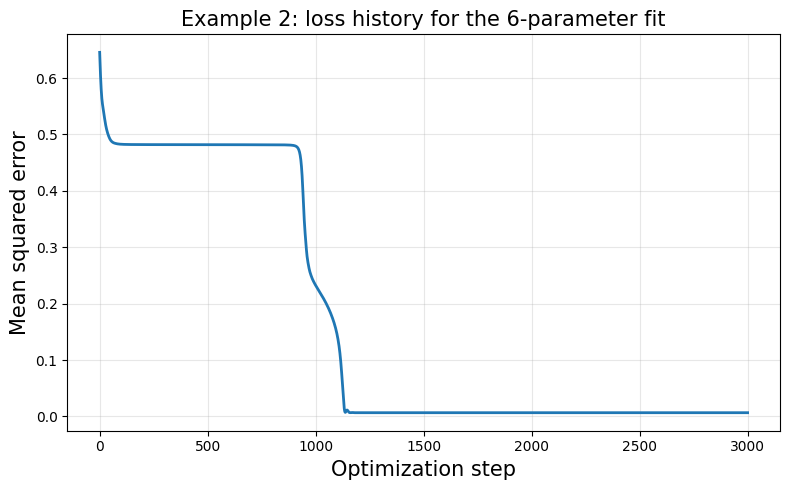

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_2, linewidth=2)
plt.xlabel("Optimization step", fontsize=15)
plt.ylabel("Mean squared error", fontsize=15)
plt.title("Example 2: loss history for the 6-parameter fit", fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Compare the fitted 6-parameter model to the data

Now we evaluate the final fitted model and compare it to the observations.

The next cell will do four things:

1. compute the final fitted parameter values,
2. print the true and fitted parameters side by side,
3. plot the fitted total signal against the noisy data,
4. also plot the two fitted peaks separately.

That last step is useful because the total fitted curve may look good, but it is also helpful to see how the model is decomposing the signal into its two components.

True A1 = 2.4000, fitted A1 = 2.3703
True mu1 = 5.0000, fitted mu1 = 5.0031
True sigma1 = 1.1000, fitted sigma1 = 1.1170
True A2 = 1.7000, fitted A2 = 1.6897
True mu2 = 13.2000, fitted mu2 = 13.2163
True sigma2 = 1.9000, fitted sigma2 = 1.8870
Final loss = 0.006587


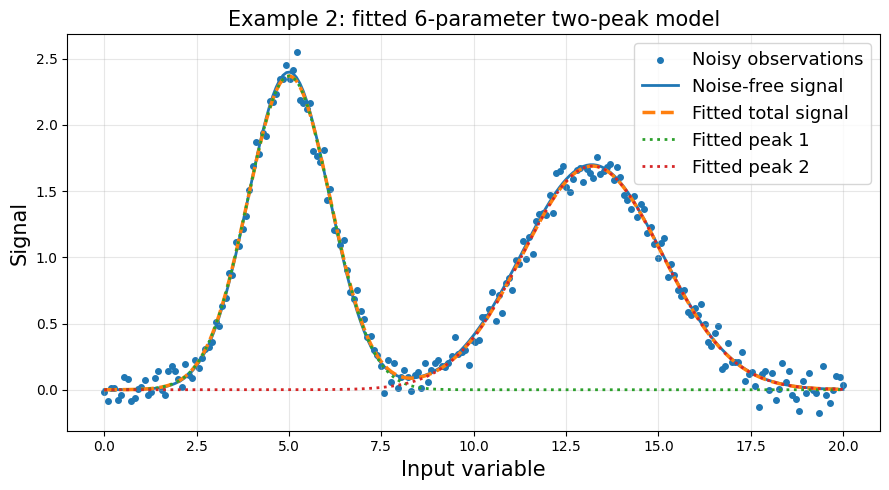

In [27]:
A1_fit, mu1_fit, sigma1_fit, A2_fit, mu2_fit, sigma2_fit = [p.detach() for p in unpack_two_peak_parameters()]
y2_fit = two_peak_model(x2, A1_fit, mu1_fit, sigma1_fit, A2_fit, mu2_fit, sigma2_fit)

peak1_fit = A1_fit * torch.exp(-0.5 * ((x2 - mu1_fit) / sigma1_fit) ** 2)
peak2_fit = A2_fit * torch.exp(-0.5 * ((x2 - mu2_fit) / sigma2_fit) ** 2)

print(f"True A1 = {A1_true.item():.4f}, fitted A1 = {A1_fit.item():.4f}")
print(f"True mu1 = {mu1_true.item():.4f}, fitted mu1 = {mu1_fit.item():.4f}")
print(f"True sigma1 = {sigma1_true.item():.4f}, fitted sigma1 = {sigma1_fit.item():.4f}")
print(f"True A2 = {A2_true.item():.4f}, fitted A2 = {A2_fit.item():.4f}")
print(f"True mu2 = {mu2_true.item():.4f}, fitted mu2 = {mu2_fit.item():.4f}")
print(f"True sigma2 = {sigma2_true.item():.4f}, fitted sigma2 = {sigma2_fit.item():.4f}")
print(f"Final loss = {loss_history_2[-1]:.6f}")

plt.figure(figsize=(9, 5))
plt.scatter(x2, y2_obs, s=16, label="Noisy observations")
plt.plot(x2, y2_clean, linewidth=2, label="Noise-free signal")
plt.plot(x2, y2_fit, "--", linewidth=2.5, label="Fitted total signal")
plt.plot(x2, peak1_fit, ":", linewidth=2, label="Fitted peak 1")
plt.plot(x2, peak2_fit, ":", linewidth=2, label="Fitted peak 2")
plt.xlabel("Input variable", fontsize=15)
plt.ylabel("Signal", fontsize=15)
plt.title("Example 2: fitted 6-parameter two-peak model", fontsize=15)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

## 19. Optional extension: visualize how selected parameters moved during optimization

When you first encounter automated optimization, it can feel mysterious.

A useful way to make it concrete is to plot the history of a few parameters over time.

The next cell shows how the optimizer adjusted:

- the first peak center,
- the second peak center,
- the two widths,
- the two peak heights.

This will help you see that optimization is really a path through parameter space, not a black box that magically jumps straight to the answer.

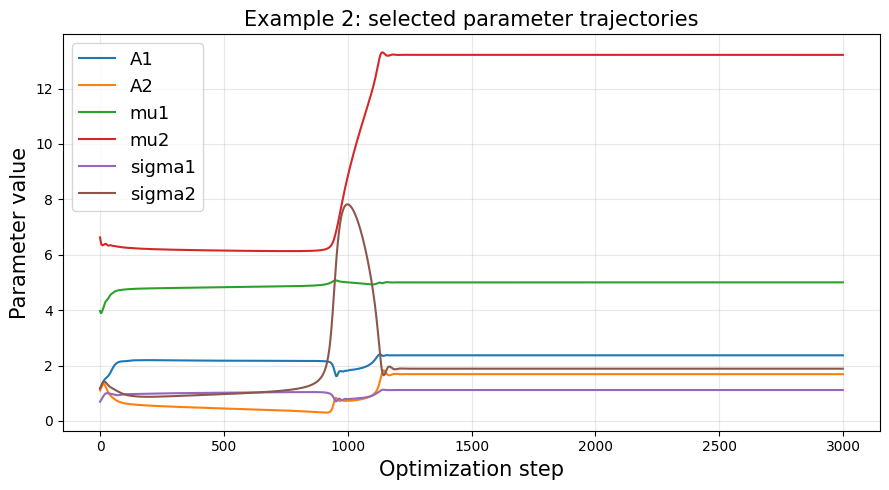

In [32]:
param_history_2_tensor = torch.tensor(param_history_2)

plt.figure(figsize=(9, 5))
plt.plot(param_history_2_tensor[:, 0], label="A1")
plt.plot(param_history_2_tensor[:, 3], label="A2")
plt.plot(param_history_2_tensor[:, 1], label="mu1")
plt.plot(param_history_2_tensor[:, 4], label="mu2")
plt.plot(param_history_2_tensor[:, 2], label="sigma1")
plt.plot(param_history_2_tensor[:, 5], label="sigma2")
plt.xlabel("Optimization step", fontsize=15)
plt.ylabel("Parameter value", fontsize=15)
plt.title("Example 2: selected parameter trajectories", fontsize=15)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

## 20. Final takeaways from this notebook

These two examples highlight the main lesson of the lecture:

- PyTorch optimization is useful far beyond very small toy problems,
- nonlinear models can still be fit effectively when everything is written in differentiable form,
- parameter constraints can be handled cleanly with parameter transformations,
- noisy data do not prevent fitting, but they do make the problem more realistic,
- once the number of parameters grows, automated optimization becomes much more practical than manual searching.

A good closing message for class is this:

> The real power of PyTorch is not just that it can evaluate a model.  
> It can also automatically differentiate through that model and use those derivatives to estimate parameters from data.

That is the bridge from numerical modeling to modern scientific machine learning.